:::{admonition} Download
:class: important

Download this notebook: **{nb-download}`plot_01_1D_basis_function.ipynb`**!

:::

In [1]:
%matplotlib inline
import warnings

# Ignore the first specific warning
warnings.filterwarnings(
    "ignore",
    message="plotting functions contained within `_documentation_utils` are intended for nemos's documentation.",
    category=UserWarning,
)

# Ignore the second specific warning
warnings.filterwarnings(
    "ignore",
    message="Ignoring cached namespace 'core'",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    message=(
        "invalid value encountered in div "
    ),
    category=RuntimeWarning,
)

from nemos._documentation_utils._myst_nb_glue import glue_two_step_convolve

glue_two_step_convolve()

(simple_basis_function)=
# Simple Basis Function

## Defining a 1D Basis Object

We'll start by defining a 1D basis function object of the type [`BSplineEval`](nemos.basis.BSplineEval).
The hyperparameters needed to initialize this class are:

- The number of basis functions, which should be a positive integer (required).
- The order of the spline, which should be an integer greater than 1 (optional, default 4 for a cubic spline).

In [2]:
import matplotlib.pylab as plt
import numpy as np
import pynapple as nap

import nemos as nmo

# configure plots some
plt.style.use(nmo.styles.plot_style)

# Initialize hyperparameters
order = 4
n_basis = 10

# Define the 1D basis function object
bspline = nmo.basis.BSplineEval(n_basis_funcs=n_basis, order=order, label="bspline")
bspline

,n_basis_funcs,10
,label,'bspline'
,order,4
,bounds,None
,fill_value,nan


We provide the convenience method `evaluate_on_grid` for evaluating the basis on an equi-spaced grid of points that makes it easier to plot and visualize all basis elements.

Text(0.5, 1.0, 'B-Spline Basis')

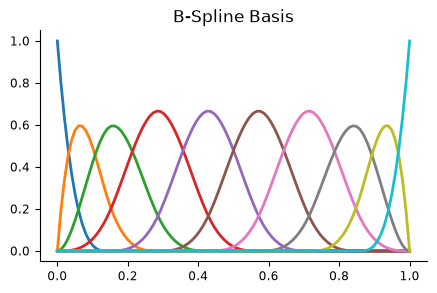

In [3]:
# evaluate the basis on 100 sample points
x, y = bspline.evaluate_on_grid(100)

fig = plt.figure(figsize=(5, 3))
plt.plot(x, y, lw=2)
plt.title("B-Spline Basis")

## Computing Features
All bases in the `nemos.basis` module perform a transformation of one or more time series into a set of features. This operation is always carried out by the method  [`compute_features`](nemos.basis._basis.Basis.compute_features).
We can group the bases into two categories depending on the type of transformation that [`compute_features`](nemos.basis._basis.Basis.compute_features) applies:

1. **Evaluation Bases**: These bases use `compute_features` to evaluate the basis directly, applying a non-linear transformation to the input. Classes in this category have names ending with "Eval," such as `BSplineEval`.

2. **Convolution Bases**: These bases use `compute_features` to convolve the input with a kernel of basis elements, using a `window_size` specified by the user. Classes in this category have names ending with "Conv", such as `BSplineConv`.

Let's see how these two categories operate:

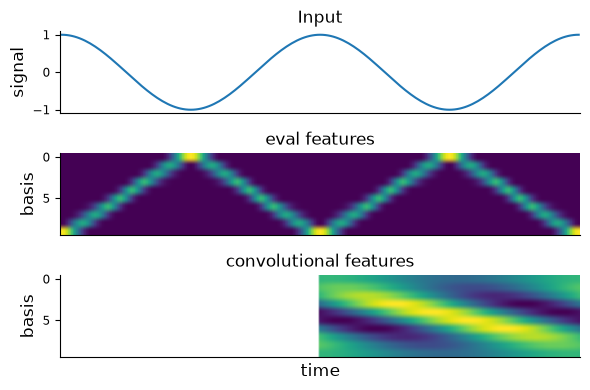

In [4]:
eval_mode = nmo.basis.BSplineEval(n_basis_funcs=n_basis, label="eval")
conv_mode = nmo.basis.BSplineConv(n_basis_funcs=n_basis, window_size=100, label="conv")

# define an input
angles = np.linspace(0, np.pi*4, 201)
y = np.cos(angles)

# compute features
eval_feature = eval_mode.compute_features(y)
conv_feature = conv_mode.compute_features(y)

# plot results
fig, axs = plt.subplots( 3, 1, sharex="all", figsize=(6, 4))

# plot signal
axs[0].set_title("Input")
axs[0].plot(y)
axs[0].set_xticks([])
axs[0].set_ylabel("signal", fontsize=12)

# plot eval results
axs[1].set_title("eval features")
axs[1].imshow(eval_feature.T, aspect="auto")
axs[1].set_xticks([])
axs[1].set_ylabel("basis", fontsize=12)

# plot conv results
axs[2].set_title("convolutional features")
axs[2].imshow(conv_feature.T, aspect="auto")
axs[2].set_xlabel("time", fontsize=12)
axs[2].set_ylabel("basis", fontsize=12)
plt.tight_layout()

:::{admonition} NaN-Padding
:class: note
Convolution is performed in "valid" mode, and then NaN-padded. The default behavior
is padding left, which makes the output feature causal.
This is why the first half of the `conv_feature` is full of NaNs and appears as white.
If you want to learn more about convolutions, as well as how and when to change defaults
check out the tutorial on [1D convolutions](convolution_background).
:::

### Multi-dimensional inputs
For inputs with more than one dimension, `compute_features` assumes the first axis represents samples. This is always valid for `pynapple` time series. For arrays, you can use [`numpy.transpose`](https://numpy.org/doc/stable/reference/generated/numpy.transpose.html) to re-arrange the axis if needed.

#### Eval Basis

For Eval bases, `compute_features` evaluates the basis and outputs a 2D feature matrix.

In [5]:
basis = nmo.basis.RaisedCosineLinearEval(n_basis_funcs=5, label="multidim")
# generate a 3D array
inp = np.random.randn(50, 3, 2)
out = basis.compute_features(inp)
out.shape

(50, 30)

For each of the $3 \times 2 = 6$ inputs, `n_basis_funcs = 5` features are computed. These are concatenated on the second axis of the feature matrix, for a total of
$3 \times 2 \times 5  = 30$ outputs.

This concatenation can be undone by the `split_by_feature` method of basis, which creates a dictionary with keys the labels of the basis and values a reshaped array.

In [6]:
basis.split_by_feature(out, axis=1)["multidim"].shape

(50, 3, 2, 5)

#### Conv Basis

For Conv bases, `compute_features` convolves each input with `n_basis_funcs` kernels and outputs a 2D feature matrix.

In [7]:
basis = nmo.basis.RaisedCosineLinearConv(n_basis_funcs=5, window_size=6)
# compute_features to perform the convolution and concatenate
out = basis.compute_features(inp)
out.shape

(50, 30)

:::{admonition} Note

This process is equivalent to performing the convolution separately with [`create_convolutional_predictor`](nemos.convolve.create_convolutional_predictor) and then reshaping the output.

```{glue} two-step-convolution-source-code
```

```{glue} two-step-convolution
```

:::

Plotting the Basis Function Elements
------------------------------------
We suggest visualizing the basis post-instantiation by evaluating each element on a set of equi-spaced sample points
and then plotting the result. The method [`Basis.evaluate_on_grid`](nemos.basis._basis.Basis.evaluate_on_grid) is designed for this, as it generates and returns
the equi-spaced samples along with the evaluated basis functions.

:::{admonition} Note

The array returned by `evaluate_on_grid(n_samples)` is the same as the kernel that is used by the Conv bases initialized with `window_sizes=n_samples`!

:::

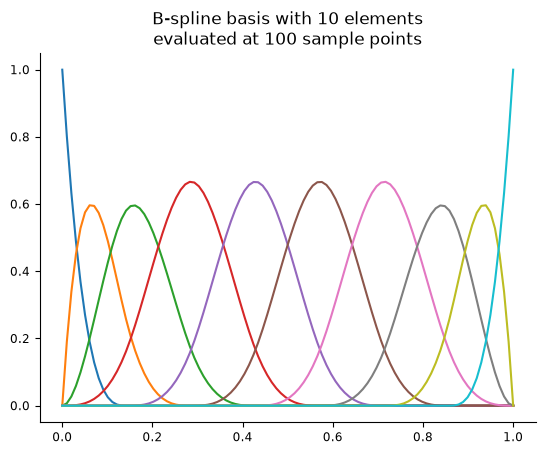

In [8]:
# Call evaluate on grid on 100 sample points to generate samples and evaluate the basis at those samples
n_samples = 100
equispaced_samples, eval_basis = bspline.evaluate_on_grid(n_samples)

# Plot each basis element
plt.figure()
plt.title(f"B-spline basis with {eval_basis.shape[1]} elements\nevaluated at {eval_basis.shape[0]} sample points")
plt.plot(equispaced_samples, eval_basis)
plt.show()

The benefits of using `evaluate_on_grid` become particularly evident when working with multidimensional basis functions. You can find more details in the [2D basis elements plotting section](plotting-2d-additive-basis-elements).

## Setting the basis support (Eval only)
Sometimes, it is useful to restrict the basis to a fixed range. This can help manage outliers or ensure that
your basis covers the same range across multiple experimental sessions.
You can specify a range for the support of your basis by setting the `bounds`
parameter at initialization of Eval bases.
Evaluating the basis at any sample outside the bounds will result in a NaN.

In [9]:
bspline_range = nmo.basis.BSplineEval(n_basis_funcs=n_basis, order=order, bounds=(0.2, 0.8))

print("Evaluated basis:")
# 0.5  is within the support, 0.1 is outside the support
print(np.round(bspline_range.compute_features([0.5, 0.1]), 3))

Evaluated basis:
[[0.         0.         0.         0.021      0.47900003 0.47900003
  0.021      0.         0.         0.        ]
 [       nan        nan        nan        nan        nan        nan
         nan        nan        nan        nan]]


Let's compare the default behavior of basis (estimating the range from the samples) with
the fixed range basis.

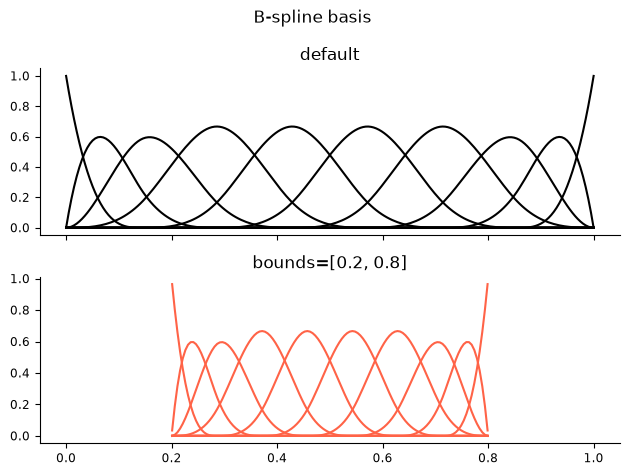

In [10]:
samples = np.linspace(0, 1, 200)
fig, axs = plt.subplots(2,1, sharex=True)
plt.suptitle("B-spline basis ")
axs[0].plot(samples, bspline.compute_features(samples), color="k")
axs[0].set_title("default")
axs[1].plot(samples, bspline_range.compute_features(samples), color="tomato")
axs[1].set_title("bounds=[0.2, 0.8]")
plt.tight_layout()